### Jigsaw Puzzle Dataset Preparation Pipeline

The objective of this notebook is to process, split, and package our raw image dataset into a structured, tile-based format suitable for training a Siamese-like or relationship prediction network.

We will walk through the following workflow:
1. **Validation**: Ensure every image meets our target resolution and channel specifications.
2. **Renaming**: Clean up filenames to follow a standard `img_idx` pattern.
3. **Splitting (Images)**: Partition the source images into `train`, `val`, and `test` splits (80/10/10 ratio).
4. **Metadata Creation**: Generate a central split manifest `images_splits.csv`.
5. **Tiling (4x4 Grid)**: Divide each image into a grid of 16 identical square tiles ($128 \times 128$ px).
6. **Reconstruction Test**: Programmatically stitch tiles back together to verify spatial integrity.
7. **Dataset Generation**: Create positive, hard negative, and easy negative training pairs, saving the final mappings in `pairs.csv`.

### Spatial Relationship and Pair Modeling

For each tile extracted from an image, we build a set of relative classification pairs. There are five possible spatial/matching classes:
* `0`: **NON-MATCH** (representing unrelated tiles)
* `1`: **LEFT** (Tile B is directly to the left of Tile A)
* `2`: **RIGHT** (Tile B is directly to the right of Tile A)
* `3`: **UP** (Tile B is directly above Tile A)
* `4`: **DOWN** (Tile B is directly below Tile A)

#### Negative Sampling Strategy:
* **Hard Negatives**: Non-neighbor tiles chosen randomly from the **same** source image (4 samples per tile).
* **Easy Negatives**: Tiles sampled from **different** images in the dataset (4 samples per tile).

*Note: You can easily adjust variables like grid size, tile dimensions, and sampling counts in the specifications cell below to suit your custom datasets.*

## Specifications and libraries

In [ ]:
!pip install opencv-python

In [ ]:
# dataset specification
num_img = 646
img_h, img_w, img_c = 512, 512, 3
grid_size = 4
tile_h, tile_w, tile_c = 128, 128, 3
num_tiles = 16
num_class = 5
random_seed = 42
hard_neg = 4
easy_neg = 4

In [ ]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import train_test_split
import cv2
from pathlib import Path
import shutil

## Step 1: Image Verification & Validation

Before processing, we must verify that all source files are readable and conform to our expected dimensions: `(512, 512, 3)`.

We will:
1. Scan the source folder for valid image formats.
2. Filter out corrupt, unreadable, or incorrectly sized images.
3. Display a random 5-image sample from the validated set.

Dataset inspection:

-------------------
Image files found: 646

Valid images: 646

Invalid images: 0

Unreadable images: 0

Expected shape: (512, 512, 3)



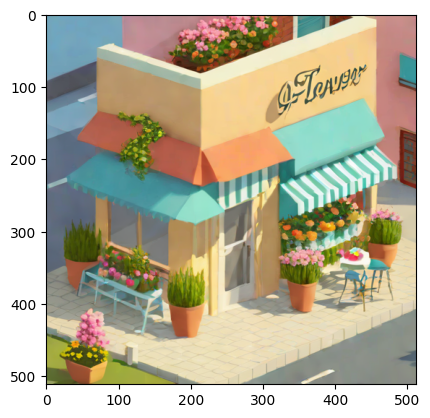

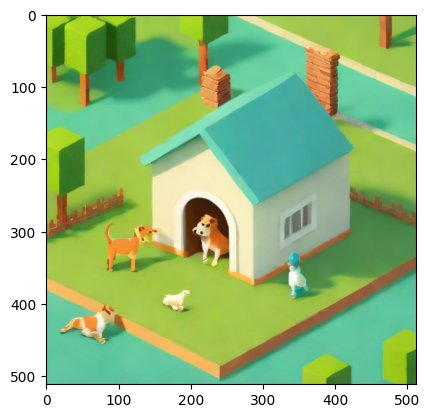

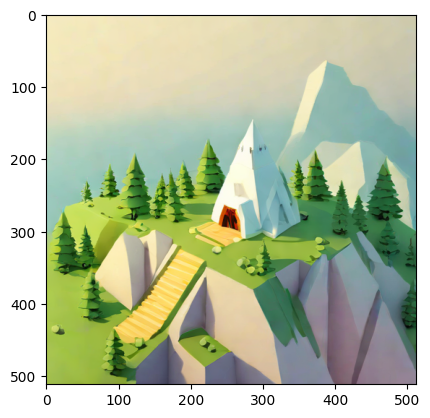

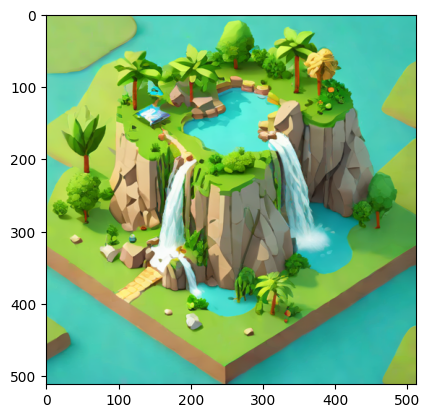

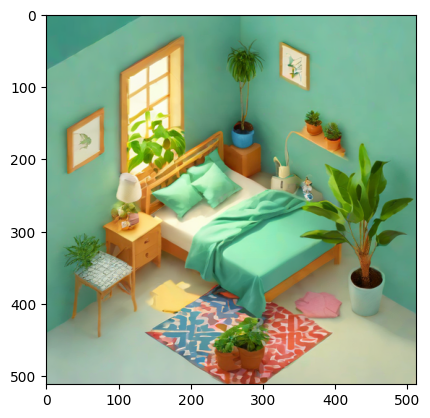

In [ ]:
# Images folder
folder_path = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/Jigsaw_Puzzles"

image_extensions = (".png", ".jpg", ".jpeg", ".webp", ".bmp")

images = []
valid_images = []
invalid_images = []
unreadable_images = []

# List of all files in the folder
files = os.listdir(folder_path)

for file_name in files:
  if file_name.lower().endswith(image_extensions):
    img_path = os.path.join(folder_path, file_name)
    # 1. all images list
    images.append(img_path)

for img_path in images:
  img = cv2.imread(img_path)
  # check for unreadable images
  if img is None:
    unreadable_images.append(img_path)
    continue
  h, w, c = img.shape

  # checking if each image has the same shape as the data specification, if not, add it to the invalid list
  if h != img_h or w != img_w or c != img_c:
    invalid_images.append({
        "img_path": img_path,
        "actual_height": h,
        "actual_width": w,
        "actual_channels": c
    })
  # adding the remaining images to the valid list
  else:
    valid_images.append(img_path)

print("Dataset inspection:\n")
print("-------------------")
print(f"Image files found: {len(images)}\n")
print(f"Valid images: {len(valid_images)}\n")
print(f"Invalid images: {len(invalid_images)}\n")
print(f"Unreadable images: {len(unreadable_images)}\n")
print(f"Expected shape: ({img_h}, {img_w}, {img_c})\n")

# display valid samples
samples = random.sample(valid_images, 5)
for path in samples:
  img = cv2.imread(path)
  rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  image = plt.imshow(rgb_img)
  plt.show()

## Step 2: Clean Filenames (Optional Overwrite)

Often, raw data comes with suffix artifacts (e.g., `img_idx_0.png`). The function below cleans up these suffixes to ensure a uniform naming format (e.g., `img_idx.png`).

*⚠️ **Warning**: This helper overwrites the file names inside your Google Drive directory. Ensure you have backed up your source images if necessary.*

In [ ]:
# function to change image file name from img_index_0 to img_index
def change_img_filename(file_path, directory):
  stem = file_path.stem # filename without extension img_index_0
  suffix = file_path.suffix # extension png

  if stem.endswith("_0"):
    new_stem = stem[:-2] # img_index
    new_filename = f"{new_stem}{suffix}" # img_index.png
    new_file_path = directory / new_filename

    # Rename the file
    file_path.rename(new_file_path)
    print(f"Renamed: {file_path.name} -> {new_filename}")


# change the images filename
directory = Path("/content/drive/MyDrive/Jigsaw_Puzzle_Project/Jigsaw_Puzzles")
for file_path in directory.iterdir():
  change_img_filename(file_path, directory)

## Step 3: Stratified Dataset Split (80/10/10)

We partition our raw source images into three mutually exclusive directories: `train`, `val`, and `test` to prevent data leakage during subsequent tiling and pairing operations.

In [ ]:
source_dir = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/Jigsaw_Puzzles"
output_dir = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/images"

# Get all image filenames
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")
images = [
    f for f in os.listdir(source_dir) if f.lower().endswith(valid_extensions)
]

train_imgs, temp = train_test_split(images, train_size=0.80, random_state=random_seed, shuffle=True)
val_imgs, test_imgs = train_test_split(temp, train_size=0.50, random_state=random_seed, shuffle=True)

splits = {"train": train_imgs, "val": val_imgs, "test": test_imgs}

# Copy files using shutil.copy2 to retain exact file features and metadata
for split_name, split_files in splits.items():
    split_folder = os.path.join(output_dir, split_name)
    os.makedirs(split_folder, exist_ok=True)

    for img_name in split_files:
        src_path = os.path.join(source_dir, img_name)
        dst_path = os.path.join(split_folder, img_name)
        shutil.copy2(src_path, dst_path)

print(
    f"Done! Copied {len(train_imgs)} train, {len(val_imgs)} val, and {len(test_imgs)} test images."
)

Done! Copied 516 train, 65 val, and 65 test images.


## Step 4: Split Manifest Export

We aggregate the folder listings into a structured DataFrame (`images_splits.csv`) representing each image, its full file path, and its assigned subset split.

In [ ]:
train_folder = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/images/train"
val_folder = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/images/val"
test_folder = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/images/test"

data = []
# 1. train
for img_filename in os.listdir(train_folder):
  image_id = os.path.splitext(os.path.basename(img_filename))[0]
  data.append({"image_id": image_id, "image_path": os.path.join(train_folder, img_filename), "split" : "train"})

# 1. val
for img_filename in os.listdir(val_folder):
  image_id = os.path.splitext(os.path.basename(img_filename))[0]
  data.append({"image_id": image_id, "image_path": os.path.join(val_folder, img_filename), "split" : "val"})

# 1. test
for img_filename in os.listdir(test_folder):
  image_id = os.path.splitext(os.path.basename(img_filename))[0]
  data.append({"image_id": image_id, "image_path": os.path.join(test_folder, img_filename), "split" : "test"})


# save the metadata file
data_df = pd.DataFrame(data)
data_df.to_csv("/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/images_splits.csv", index=False)

## Step 5: Grid Tiling & Slicing

Now, we slice each full $512 \times 512$ image into a $4 \times 4$ grid, generating 16 individual $128 \times 128$ tile files. The coordinate space is labeled dynamically.

### Tile Cropping Helper

This utility slices a loaded image array into non-overlapping square crops using pixel coordinates calculated based on grid dimensions.

In [ ]:
def split_image(image, grid_size, tile_h, tile_w):
  tiles = [] # store tiles
  for i in range(grid_size):     # Rows
    for j in range(grid_size): # Columns
      # Calculate pixel coordinates for cropping
      y1 = i * tile_h
      y2 = y1 + tile_h
      x1 = j * tile_w
      x2 = x1 + tile_w
      tile = image[y1:y2, x1:x2]
      tiles.append(tile)
  return tiles

### Processing Folders and Building Tile Metadata

We process the images split-by-split, save each crop with a unique coordinate-encoded filename, and export split-specific manifests.

In [ ]:
""" This function take a dir contain images, then split these images and save the tiles into out_dir, create a meta
csv file contain info about the tiles in the folder, this file will be part of the tiles.csv """
def split_images_per_folder(source_dir, out_dir, split, meta_path):
  os.makedirs(out_dir, exist_ok=True)
  os.makedirs(meta_path, exist_ok=True)
  data = []
  # 1. Split each image in the source folder
  for img_filename in os.listdir(source_dir):
    if not img_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
      continue
    img_path = os.path.join(source_dir, img_filename)
    image = cv2.imread(img_path)
    if image is None:
      print("Error: Could not load image. Check the file path.")
      continue
    else:
      tiles = split_image(image, grid_size, tile_h, tile_w)

    # 2. Save the tiles and metadata
    image_name, extension = os.path.splitext(os.path.basename(img_filename))
    idx = image_name.split('_')[-1] if '_' in image_name else image_name
    for index, tile in enumerate(tiles):
      tile_name = f"tile_{index}_img_{idx}{extension}" # tile_0_img_367.png
      save_path = os.path.join(out_dir, tile_name)
      success = cv2.imwrite(save_path, tile)
      if success:
        pass
      else:
        print(f"Failed to save {tile_name}.\n")
      data.append({
        "tile_id" : os.path.splitext(os.path.basename(tile_name))[0],
        "img_id" : image_name,
        "row" : index // grid_size,
        "col" : index % grid_size,
        "tile_path" : save_path,
        "split" : split
      })
  data_df = pd.DataFrame(data)
  meta_name = f"{split}_tiles.csv"
  path = os.path.join(meta_path, meta_name)
  data_df.to_csv(path, index=False)

In [ ]:
train_img_path = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/images/train"
val_img_path = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/images/val"
test_img_path = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/images/test"

train_tiles = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/train"
val_tiles = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/val"
test_tiles = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test"

meta_path = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata"

split_images_per_folder(train_img_path, train_tiles, "train", meta_path)
print("Processing complete. Train tiles metadata saved")

split_images_per_folder(val_img_path, val_tiles, "val", meta_path)
print("Processing complete. Val tiles metadata saved")

split_images_per_folder(test_img_path, test_tiles, "test", meta_path)
print("Processing complete. Test tiles metadata saved")

Processing complete. Train tiles metadata saved
Processing complete. Val tiles metadata saved
Processing complete. Test tiles metadata saved


In [ ]:
# concatenate the meta files into one main file
files = ["/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/train_tiles.csv",
"/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/val_tiles.csv",
         "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/test_tiles.csv"]

combined_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

path = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/tiles.csv"
combined_df.to_csv(path, index=False)
print("Processing complete. Tiles metadata saved to:", path)

Processing complete. Tiles metadata saved to: /content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/tiles.csv


## Step 6: Reconstruction & Validation Tests

To guarantee that no spatial distortion occurred during slicing, we programmatically reconstruct full images from their tiles and perform pixel-by-pixel comparisons.

In [ ]:
# a function that takes images' tiles and reconstruct the full image
def image_reconstruct(metadata_path, img_id):
    metadata = pd.read_csv(metadata_path)
    tiles_df = metadata[metadata['img_id'] == img_id]

    full_image = np.zeros((grid_size * tile_h, grid_size * tile_w, tile_c), dtype="uint8")

    for _, row in tiles_df.iterrows():
       path = row['tile_path']  # Path to the tile image
       r = int(row['row'])      # Grid row index (0-3)
       c = int(row['col'])      # Grid col index (0-3)

       # Load tile array from path
       tile = cv2.imread(path)

       # Compute pixel bounds
       row_start, row_end = r * tile_h, (r + 1) * tile_h
       col_start, col_end = c * tile_w, (c + 1) * tile_w

       # Assign tile to canvas
       full_image[row_start:row_end, col_start:col_end] = tile

    return full_image

In [ ]:
def compare_images(img1, img2):
  # 1. Compare shapes
  shape_original = img1.shape
  shape_reconstructed = img2.shape

  print(f"Shape of original image: {shape_original}")
  print(f"Shape of reconstructed image: {shape_reconstructed}")

  if shape_original == shape_reconstructed:
    print("Image shapes are identical.")

    # 2. Compare pixel-wise if shapes are the same
    are_equal_pixels = np.array_equal(img1, img2)

    if are_equal_pixels:
        print("Images are pixel-wise identical.")
    else:
        print("Images have the same shape but are not pixel-wise identical.")
        # You can also find where they differ
        diff_pixels = np.sum(img_rgb != full_img)
        print(f"Number of differing pixels: {diff_pixels}")
  else:
    print("Image shapes are different, so they cannot be pixel-wise identical.")

_____Original Image_____



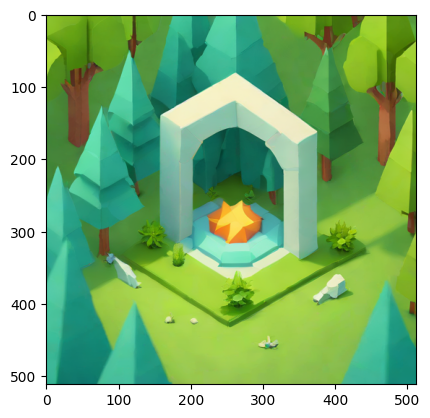

_____Reconstructed Image_____



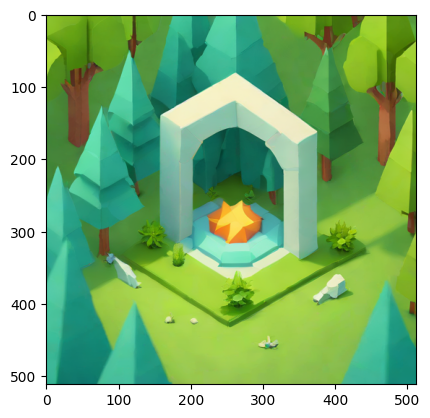

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



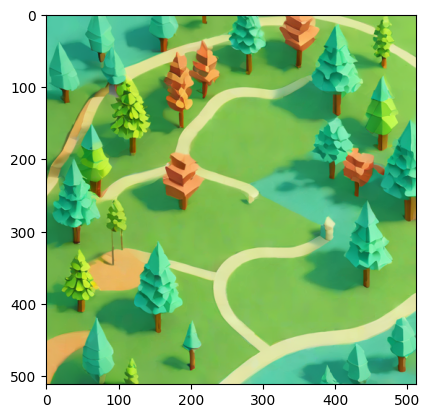

_____Reconstructed Image_____



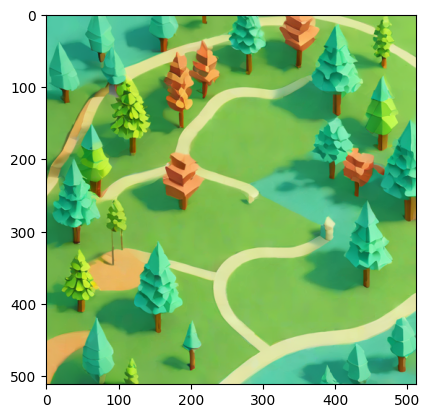

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



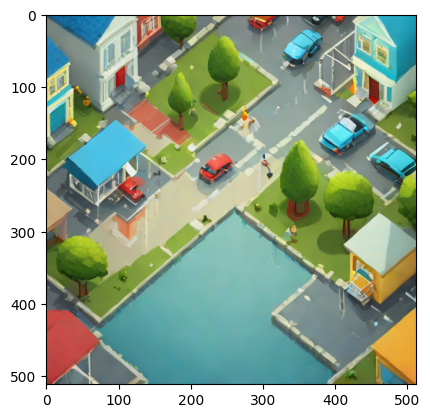

_____Reconstructed Image_____



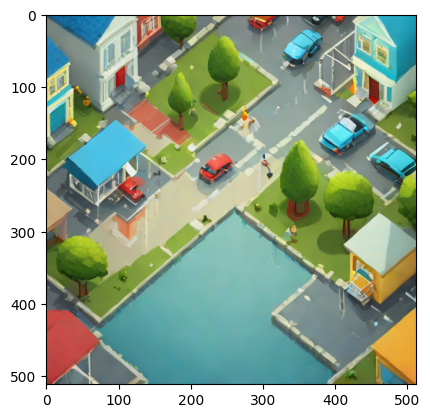

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



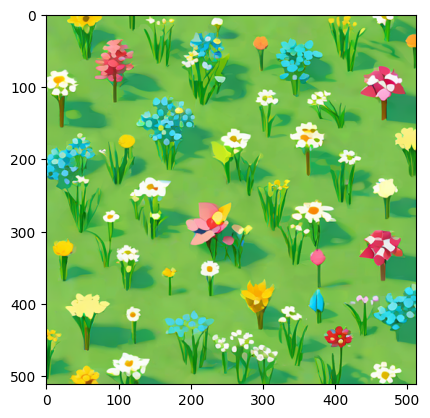

_____Reconstructed Image_____



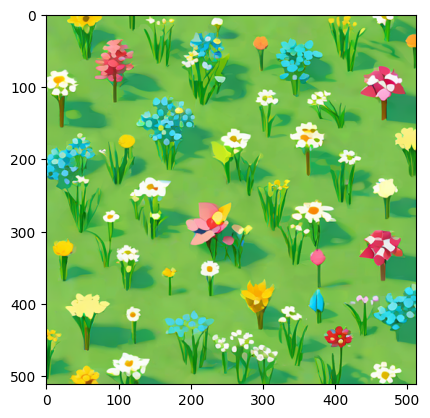

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



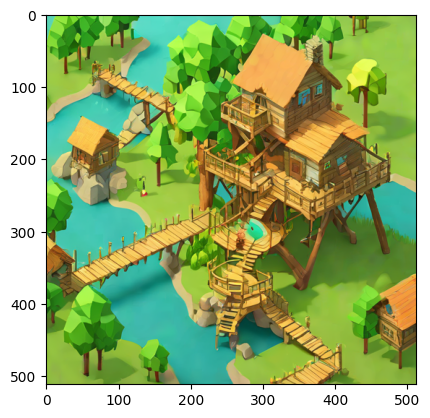

_____Reconstructed Image_____



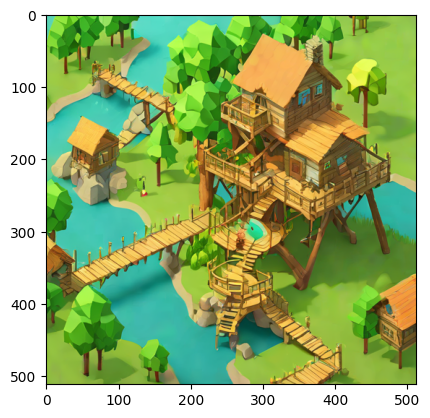

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



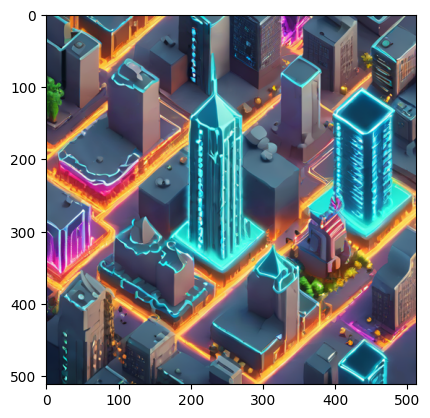

_____Reconstructed Image_____



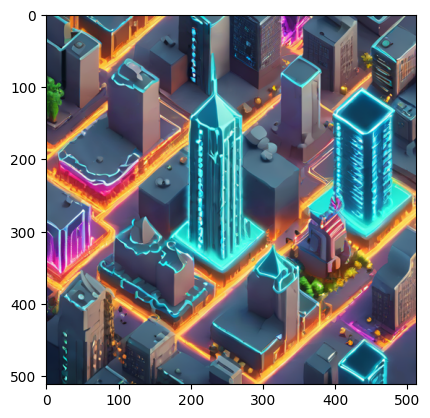

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



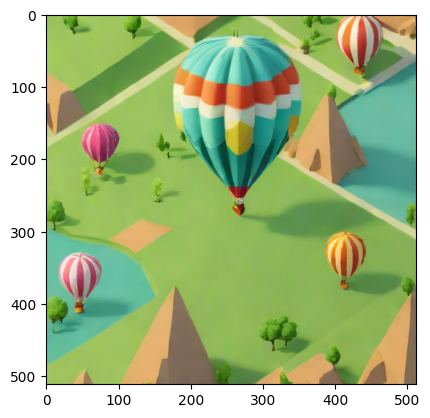

_____Reconstructed Image_____



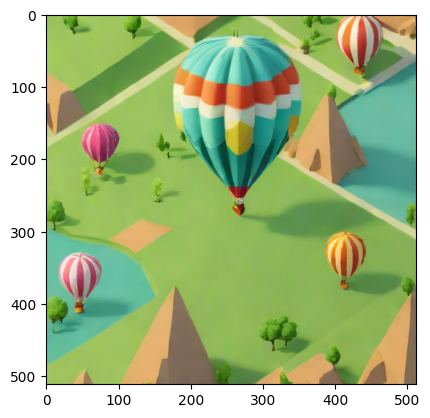

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



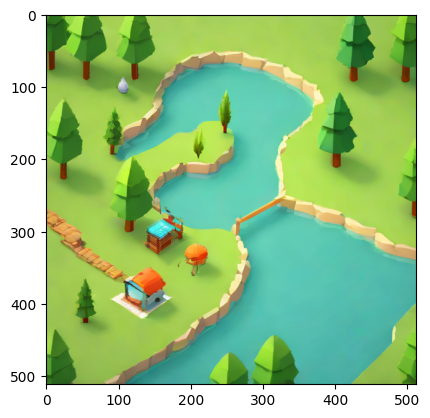

_____Reconstructed Image_____



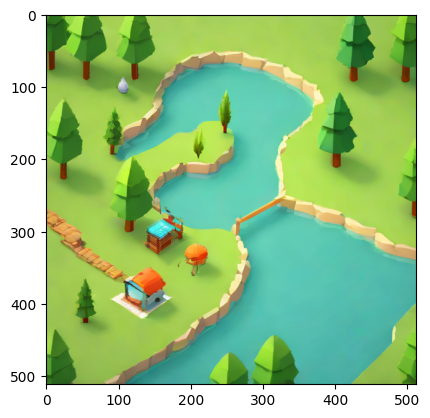

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



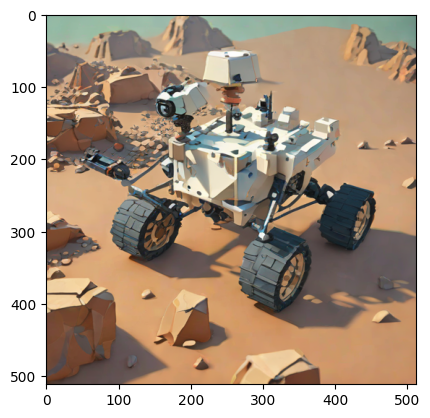

_____Reconstructed Image_____



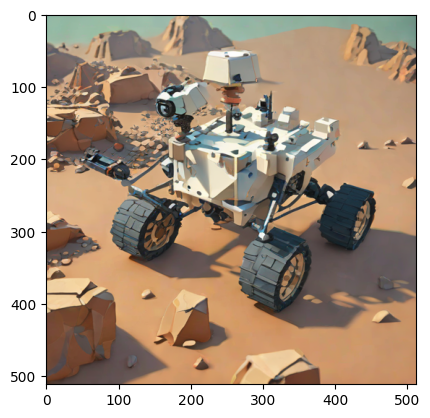

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------

_____Original Image_____



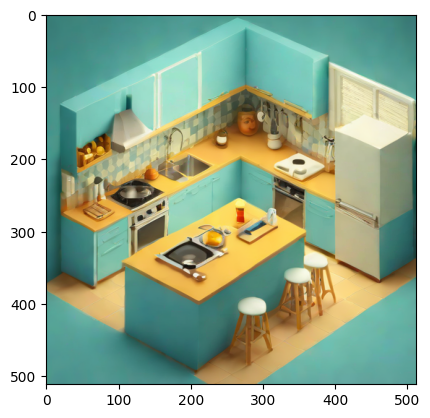

_____Reconstructed Image_____



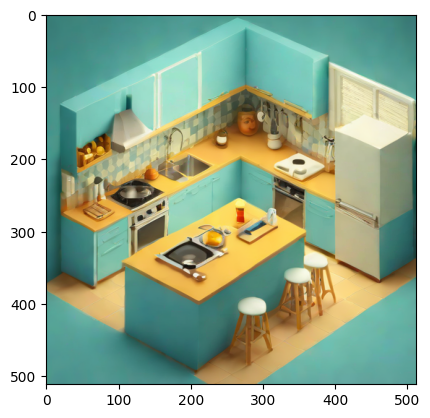

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.
------------------------------



In [ ]:
# Test 10 samples

# path to the images meta file to get the image_id
images_split = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/images_splits.csv"
# path to the tiles meta file to reconstruct the images
tiles = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/tiles.csv"

images_df = pd.read_csv(images_split)

# start a loop over 10 samples
for _ in range(10):
  # Get 1 random row
  random_row = images_df.sample()
  img_id = random_row['image_id'].item()
  img_path = random_row['image_path'].item()
  # reconstruct image
  full_img = image_reconstruct(tiles, img_id)
  full_img = cv2.cvtColor(full_img, cv2.COLOR_BGR2RGB)
  # display both images
  print("_____Original Image_____\n")
  img = cv2.imread(img_path)
  if img is None:
    print("Error! can't load image\n")
  else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_img = plt.imshow(img_rgb)
    plt.show()

  print("_____Reconstructed Image_____\n")
  reconstructed_img = plt.imshow(full_img)
  plt.show()
  # compare the 2 images
  compare_images(img_rgb, full_img)
  print("------------------------------\n")

### Automated Integrity Reporting

Below, we define a complete validation framework to inspect our generated tiles. It checks for missing files, shape integrity, split consistency, and duplicated coordinates.

In [ ]:
def validate_dataset(
    csv_path: str,
    base_dir: str = "",
    expected_tiles_per_img: int = 16,
    expected_shape: tuple = (128, 128, 3),
    expected_grid: tuple = (4, 4),
) -> dict:
    """Validates dataset structure, tile dimensions, file existence, and grid layout.

    Args:
        csv_path: Path to the metadata CSV file.
        base_dir: Optional root directory path if tile_path values are relative.
        expected_tiles_per_img: Number of expected tiles per image (default: 16).
        expected_shape: Expected (height, width, channels) of each tile image.
        expected_grid: Expected (rows, cols) grid dimensions (default: 4x4).

    Returns:
        dict: Summary metrics of the validation.
    """
    df = pd.read_csv(csv_path)

    expected_rows = set(range(expected_grid[0]))
    expected_cols = set(range(expected_grid[1]))

    # 1 & 2. Count images, tiles, and verify tile uniqueness
    total_images = df["img_id"].nunique()
    total_tiles = len(df)
    expected_total_tiles = total_images * expected_tiles_per_img

    # Check images with exactly 16 tiles
    tiles_per_img = df.groupby("img_id").size()
    imgs_with_correct_tile_count = (
        tiles_per_img == expected_tiles_per_img
    ).sum()

    # Verify tile_id uniqueness mapping to a single img_id
    tile_to_img = df.groupby("tile_id")["img_id"].nunique()
    shared_tile_ids = (tile_to_img > 1).sum()

    # 5. Check grid positions (row/col) and duplicate positions
    duplicate_positions = 0
    invalid_grid_imgs = 0

    if "row" in df.columns and "col" in df.columns:
        # Check for duplicate (row, col) entries within the same img_id
        dup_mask = df.duplicated(subset=["img_id", "row", "col"], keep=False)
        duplicate_positions = df[dup_mask]["img_id"].nunique()

        # Check if every img_id contains full set of expected rows and cols
        for img_id, group in df.groupby("img_id"):
            img_rows = set(group["row"])
            img_cols = set(group["col"])
            if img_rows != expected_rows or img_cols != expected_cols:
                invalid_grid_imgs += 1

    # 3 & 4. Verify file existence and tile image shapes using OpenCV
    missing_files = 0
    invalid_shapes = 0

    for idx, row in df.iterrows():
        path = str(row["tile_path"])
        if base_dir:
            path = os.path.join(base_dir, path)

        if not os.path.exists(path):
            missing_files += 1
            continue

        img = cv2.imread(path)
        if img is None:
            missing_files += 1
        elif img.shape != expected_shape:
            invalid_shapes += 1

    # Check split inconsistencies (if a 'split' column exists)
    split_inconsistencies = 0
    if "split" in df.columns:
        splits_per_img = df.groupby("img_id")["split"].nunique()
        split_inconsistencies = (splits_per_img > 1).sum()

    # Format and print output
    print("Dataset validation")
    print("-" * 18)
    print(f"{'Images:':<24} {total_images}")
    print(f"{'Tiles:':<24} {total_tiles}")
    print(f"{'Expected tiles:':<24} {expected_total_tiles}")
    print(
        f"{'Images with 16 tiles:':<24} {imgs_with_correct_tile_count} / {total_images}"
    )
    print(f"{'Invalid tile shapes:':<24} {invalid_shapes}")
    print(f"{'Missing tile files:':<24} {missing_files}")
    print(f"{'Duplicate positions:':<24} {duplicate_positions}")
    print(f"{'Split inconsistencies:':<24} {split_inconsistencies}")

    return {
        "images": total_images,
        "tiles": total_tiles,
        "expected_tiles": expected_total_tiles,
        "valid_images": imgs_with_correct_tile_count,
        "invalid_shapes": invalid_shapes,
        "missing_files": missing_files,
        "duplicate_positions": duplicate_positions,
        "split_inconsistencies": split_inconsistencies,
        "shared_tile_ids": shared_tile_ids,
        "invalid_grid_imgs": invalid_grid_imgs,
    }

In [ ]:
tiles_csv_path = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/tiles.csv"
validate_dataset = validate_dataset(tiles_csv_path)

Dataset validation
------------------
Images:                  646
Tiles:                   10336
Expected tiles:          10336
Images with 16 tiles:    646 / 646
Invalid tile shapes:     0
Missing tile files:      0
Duplicate positions:     0
Split inconsistencies:   0


## Step 7: Pair Generation & Sampling

Here, we define spatial lookup relationships to search for adjacent tiles (Positives) and select appropriate negatives (Hard and Easy) for our final contrastive/relational training pairs.

In [ ]:
def get_positive_neighbors(img_id, row, col, tile_lookup, max_rows=4, max_cols=4):
    """
    Finds cardinal neighbors and verifies they actually exist in tile_lookup for this img_id.
    """
    directions = {
        "LEFT": (row, col - 1),
        "RIGHT": (row, col + 1),
        "UP": (row - 1, col),
        "DOWN": (row + 1, col)
    }

    valid_positives = {}
    for rel_name, (r, c) in directions.items():
        # Check boundary conditions
        if 0 <= r < max_rows and 0 <= c < max_cols:
            # Verify the tile exists in the dataset for this specific img_id
            if (img_id, r, c) in tile_lookup:
                valid_positives[rel_name] = (r, c)

    return valid_positives

### Verifying Positive Neighbors

We can test our positive spatial layout mapping on a random image to see if it correctly finds all cardinal neighbors.

In [ ]:
# test the function

# Read tiles dataset
tiles_csv = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/tiles.csv"
df = pd.read_csv(tiles_csv)

image_id = random.choice(df['img_id'].tolist())
image_tiles = df[df['img_id'] == image_id]

tile_lookup = (
    image_tiles[['img_id', 'row', 'col', 'tile_id', 'tile_path', 'split']]
    .set_index(['img_id', 'row', 'col'])
    .to_dict(orient='index')
)
counter = 0
for anchor in image_tiles.itertuples():
  pos_neighbors = get_positive_neighbors(anchor.img_id, anchor.row, anchor.col, tile_lookup, max_rows=4, max_cols=4)
  num_neighbors = len([t for t in pos_neighbors.values() if t is not None])
  counter += num_neighbors
  print(f"Image: {image_id}\n")
  print(f"Tile: {anchor.tile_id}\n")
  print(f"tile_row: {anchor.row}, tile_col: {anchor.col}\n")
  print(f"positive neighbors: {pos_neighbors}\n")
  print("----------------------------")
print(f"Number of positive relations in the image is: {counter}\n")

Image: img_146

Tile: tile_0_img_146

tile_row: 0, tile_col: 0

positive neighbors: {'RIGHT': (0, 1), 'DOWN': (1, 0)}

----------------------------
Image: img_146

Tile: tile_1_img_146

tile_row: 0, tile_col: 1

positive neighbors: {'LEFT': (0, 0), 'RIGHT': (0, 2), 'DOWN': (1, 1)}

----------------------------
Image: img_146

Tile: tile_2_img_146

tile_row: 0, tile_col: 2

positive neighbors: {'LEFT': (0, 1), 'RIGHT': (0, 3), 'DOWN': (1, 2)}

----------------------------
Image: img_146

Tile: tile_3_img_146

tile_row: 0, tile_col: 3

positive neighbors: {'LEFT': (0, 2), 'DOWN': (1, 3)}

----------------------------
Image: img_146

Tile: tile_4_img_146

tile_row: 1, tile_col: 0

positive neighbors: {'RIGHT': (1, 1), 'UP': (0, 0), 'DOWN': (2, 0)}

----------------------------
Image: img_146

Tile: tile_5_img_146

tile_row: 1, tile_col: 1

positive neighbors: {'LEFT': (1, 0), 'RIGHT': (1, 2), 'UP': (0, 1), 'DOWN': (2, 1)}

----------------------------
Image: img_146

Tile: tile_6_img_146


### Hard Negative Sampling Function

Hard negatives are tiles from the same parent image that do not share a direct border with our anchor tile.

In [ ]:
def get_hard_negatives(img_id, row, col, image_grids, pos_coords_set, num_samples=3):
    """
    Samples non-neighbor tiles strictly from the same image's 16 tiles.
    """
    # Fetch all existing tiles for this specific image
    img_tiles = image_grids.get(img_id, [])

    # Exclude the anchor tile and its positive neighbors
    hard_candidates = [
        coord for coord in img_tiles
        if coord not in pos_coords_set and coord != (row, col)
    ]

    return random.sample(hard_candidates, min(num_samples, len(hard_candidates)))

### Testing Hard Negative Sampling

Let's test this strategy on a random image to ensure that no adjacent positive neighbors are selected as hard negatives.

In [ ]:
# test the function

# Read tiles dataset
tiles_csv = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/tiles.csv"
df = pd.read_csv(tiles_csv)

image_id = random.choice(df['img_id'].tolist())
image_tiles = df[df['img_id'] == image_id]

tile_lookup = (
    image_tiles[['img_id', 'row', 'col', 'tile_id', 'tile_path', 'split']]
    .set_index(['img_id', 'row', 'col'])
    .to_dict(orient='index')
)

# 2. Per-image grid map: img_id -> list of available (row, col) coordinate tuples
image_grids = df.groupby('img_id')[['row', 'col']].apply(
    lambda g: list(zip(g['row'], g['col']))
).to_dict()

counter = 0
for anchor in image_tiles.itertuples():
  pos_neighbors = get_positive_neighbors(anchor.img_id, anchor.row, anchor.col, tile_lookup, max_rows=4, max_cols=4)
  pos_coords_set = set(pos_neighbors.values())
  neg_neighbors = get_hard_negatives(image_id, anchor.row, anchor.col, image_grids, pos_coords_set, num_samples=3)
  print(f"Image: {anchor.img_id}\n")
  print(f"Tile: {anchor.tile_id}\n")
  print(f"tile_row: {anchor.row}, tile_col: {anchor.col}\n")
  print(f"Neegative neighbors: {neg_neighbors}\n")
  print("-------------------------------")

Image: img_426

Tile: tile_0_img_426

tile_row: 0, tile_col: 0

Neegative neighbors: [(2, 0), (0, 2), (1, 2)]

-------------------------------
Image: img_426

Tile: tile_1_img_426

tile_row: 0, tile_col: 1

Neegative neighbors: [(3, 2), (3, 0), (1, 3)]

-------------------------------
Image: img_426

Tile: tile_2_img_426

tile_row: 0, tile_col: 2

Neegative neighbors: [(2, 3), (1, 0), (3, 1)]

-------------------------------
Image: img_426

Tile: tile_3_img_426

tile_row: 0, tile_col: 3

Neegative neighbors: [(2, 0), (3, 1), (2, 1)]

-------------------------------
Image: img_426

Tile: tile_4_img_426

tile_row: 1, tile_col: 0

Neegative neighbors: [(0, 1), (1, 2), (3, 1)]

-------------------------------
Image: img_426

Tile: tile_5_img_426

tile_row: 1, tile_col: 1

Neegative neighbors: [(1, 3), (0, 2), (2, 3)]

-------------------------------
Image: img_426

Tile: tile_6_img_426

tile_row: 1, tile_col: 2

Neegative neighbors: [(2, 3), (0, 0), (2, 0)]

-------------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Easy Negative Sampling Function

Easy negatives are randomly selected tiles from completely different parent images within the same split (e.g., a train tile paired with another train tile from a different image).

In [ ]:
def easy_negative_neighbors(df, current_img_id, split_name=None, num_samples=3):
    # Filter out current image and restrict to the same split if provided
    mask = df['img_id'] != current_img_id
    if split_name is not None:
        mask &= (df['split'] == split_name)

    candidates = df[mask]

    # Sample directly using pandas for high performance
    sampled_df = candidates.sample(n=min(num_samples, len(candidates)))

    # Return as list of dictionaries
    return sampled_df[['img_id', 'row', 'col']].to_dict(orient='records')

## Step 8: Build and Export Final Pairs Manifest

We loop through all tiles in the dataset to construct positive, hard-negative, and easy-negative pairings. The result is written to `pairs.csv`.

In [ ]:
import pandas as pd
import random

# Define missing class label mapping
class_label = {
    "LEFT": 1,
    "RIGHT": 2,
    "UP": 3,
    "DOWN": 4,
    "no_match": 0
}

# Read tiles dataset
tiles_csv = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/tiles.csv"
df = pd.read_csv(tiles_csv)

pairs = []
pair_counter = 0

# 1. Full lookup dictionary: (img_id, row, col) -> tile metadata
tile_lookup = (
    df[['img_id', 'row', 'col', 'tile_id', 'tile_path', 'split']]
    .set_index(['img_id', 'row', 'col'])
    .to_dict(orient='index')
)

# 2. Per-image grid map: img_id -> list of available (row, col) coordinate tuples
image_grids = df.groupby('img_id')[['row', 'col']].apply(
    lambda g: list(zip(g['row'], g['col']))
).to_dict()

# Main processing loop
for anchor in df.itertuples():
    anchor_img = anchor.img_id
    anchor_tile = anchor.tile_id
    anchor_row = anchor.row
    anchor_col = anchor.col
    anchor_split = anchor.split
    anchor_path = anchor.tile_path

    # --- 1. Get Positives ---
    pos_neighbors = get_positive_neighbors(anchor_img, anchor_row, anchor_col, tile_lookup)
    pos_coords_set = set(pos_neighbors.values())

    for rel_label, (pos_r, pos_c) in pos_neighbors.items():
        target_tile = tile_lookup[(anchor_img, pos_r, pos_c)]
        pairs.append({
            "pair_id": pair_counter,
            "image_id_a": anchor_img,
            "image_id_b": anchor_img,
            "tile_id_a": anchor_tile,
            "tile_id_b": target_tile['tile_id'],
            "tile_path_a": anchor_path,
            "tile_path_b": target_tile['tile_path'],
            "row_a": anchor_row,
            "col_a": anchor_col,
            "row_b": pos_r,
            "col_b": pos_c,
            "label": class_label[rel_label],
            "label_name": rel_label,
            "pair_type": "positive",
            "split": anchor_split
        })
        pair_counter += 1

    # --- 2. Get Hard Negatives ---
    hard_neg_coords = get_hard_negatives(anchor_img, anchor_row, anchor_col, image_grids, pos_coords_set, num_samples=3)
    for neg_r, neg_c in hard_neg_coords:
        target_tile = tile_lookup[(anchor_img, neg_r, neg_c)]
        pairs.append({
            "pair_id": pair_counter,
            "image_id_a": anchor_img,
            "image_id_b": anchor_img,
            "tile_id_a": anchor_tile,
            "tile_id_b": target_tile['tile_id'],
            "tile_path_a": anchor_path,
            "tile_path_b": target_tile['tile_path'],
            "row_a": anchor_row,
            "col_a": anchor_col,
            "row_b": neg_r,
            "col_b": neg_c,
            "label": class_label["no_match"],
            "label_name": "no_match",
            "pair_type": "hard",
            "split": anchor_split
        })
        pair_counter += 1

    # --- 3. Get Easy Negatives ---
    easy_negs = easy_negative_neighbors(df, anchor_img, split_name=anchor_split, num_samples=3)
    for easy_tile_dict in easy_negs:
        easy_img_id = easy_tile_dict['img_id']
        easy_r = easy_tile_dict['row']
        easy_c = easy_tile_dict['col']

        target_tile = tile_lookup[(easy_img_id, easy_r, easy_c)]
        pairs.append({
            "pair_id": pair_counter,
            "image_id_a": anchor_img,
            "image_id_b": easy_img_id,
            "tile_id_a": anchor_tile,
            "tile_id_b": target_tile['tile_id'],
            "tile_path_a": anchor_path,
            "tile_path_b": target_tile['tile_path'],
            "row_a": anchor_row,
            "col_a": anchor_col,
            "row_b": easy_r,
            "col_b": easy_c,
            "label": class_label["no_match"],
            "label_name": "no_match",
            "pair_type": "easy",
            "split": anchor_split
        })
        pair_counter += 1

# Export to CSV
pairs_df = pd.DataFrame(pairs)
pairs_df.to_csv("/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/pairs.csv", index=False)

## Step 9: Final Quality Assurance (QA)

Before finishing, we execute a comprehensive suite of checks on `pairs.csv` to ensure structural alignment, correct labels, split hygiene, and reciprocity symmetry.

In [ ]:
import pandas as pd

def verify_pairs_csv(csv_path: str):
    """
    Verifies a pairs CSV dataset for consistency, spatial relationships,
    split integrity, and missing values. Generates a detailed report.
    """
    df = pd.read_csv(csv_path)

    report = []
    report.append("=" * 60)
    report.append("          PAIRS DATASET VERIFICATION REPORT          ")
    report.append("=" * 60)
    report.append(f"Total Rows Analyzed: {len(df):,}\n")

    # Define directional symmetry rules
    opposite_map = {
        "LEFT": "RIGHT",
        "RIGHT": "LEFT",
        "UP": "DOWN",
        "DOWN": "UP"
    }

    errors = 0
    warnings = 0

    # 1. Structural Checks (Columns, IDs, Missing Values)
    report.append("--- 1. STRUCTURAL & INTEGRITY CHECKS ---")

    required_cols = [
        'pair_id', 'image_id_a', 'image_id_b', 'tile_id_a', 'tile_id_b',
        'tile_path_a', 'tile_path_b', 'row_a', 'col_a', 'row_b', 'col_b',
        'label', 'label_name', 'pair_type', 'split'
    ]

    missing_cols = set(required_cols) - set(df.columns)
    if missing_cols:
        report.append(f"[FAIL] Missing required columns: {missing_cols}")
        errors += 1
    else:
        report.append("[PASS] All required columns present.")

    # Unique pair_id
    if df['pair_id'].nunique() == len(df):
        report.append("[PASS] 'pair_id' values are completely unique.")
    else:
        duplicates = len(df) - df['pair_id'].nunique()
        report.append(f"[FAIL] Found {duplicates:,} duplicate 'pair_id' values.")
        errors += 1

    # Missing values check
    null_counts = df[required_cols].isnull().sum().sum()
    if null_counts == 0:
        report.append("[PASS] Zero missing (NaN) values detected.")
    else:
        report.append(f"[FAIL] Detected {null_counts:,} total missing values across columns.")
        errors += 1


    # 2. Split Integrity Checks
    report.append("\n--- 2. SPLIT INTEGRITY CHECKS ---")

    # Check if any image spans across multiple splits
    img_split_a = df.groupby('image_id_a')['split'].nunique()
    img_split_b = df.groupby('image_id_b')['split'].nunique()
    cross_split_a = img_split_a[img_split_a > 1]
    cross_split_b = img_split_b[img_split_b > 1]

    if len(cross_split_a) == 0 and len(cross_split_b) == 0:
        report.append("[PASS] No image ID spans across multiple splits.")
    else:
        report.append(f"[FAIL] Information Leakage: Images span multiple splits.")
        errors += 1

    # Distribution per split
    split_counts = df['split'].value_counts().to_dict()
    report.append(f"[INFO] Split Breakdown: {split_counts}")


    # 3. Spatial & Pair Type Consistency
    report.append("\n--- 3. SPATIAL & PAIR TYPE LOGIC ---")

    # Positive Pairs
    positives = df[df['pair_type'] == 'positive']
    diff_img_pos = positives[positives['image_id_a'] != positives['image_id_b']]
    if len(diff_img_pos) == 0:
        report.append("[PASS] All positive pairs share the exact same source image.")
    else:
        report.append(f"[FAIL] Found {len(diff_img_pos)} positive pairs from different images.")
        errors += 1

    # Coordinate Offset Verification for Positives
    coord_mismatches = 0
    for _, row in positives.iterrows():
        r_a, c_a = row['row_a'], row['col_a']
        r_b, c_b = row['row_b'], row['col_b']
        direction = row['label_name']

        if direction == "LEFT" and not (r_a == r_b and c_b == c_a - 1):
            coord_mismatches += 1
        elif direction == "RIGHT" and not (r_a == r_b and c_b == c_a + 1):
            coord_mismatches += 1
        elif direction == "UP" and not (r_b == r_a - 1 and c_a == c_b):
            coord_mismatches += 1
        elif direction == "DOWN" and not (r_b == r_a + 1 and c_a == c_b):
            coord_mismatches += 1

    if coord_mismatches == 0:
        report.append("[PASS] All positive spatial offsets (LEFT, RIGHT, UP, DOWN) strictly align with coordinates.")
    else:
        report.append(f"[FAIL] Found {coord_mismatches} positive pairs with incorrect spatial coordinate offsets.")
        errors += 1

    # Hard Negatives
    hard_negs = df[df['pair_type'] == 'hard']
    diff_img_hard = hard_negs[hard_negs['image_id_a'] != hard_negs['image_id_b']]
    if len(diff_img_hard) == 0:
        report.append("[PASS] All hard negatives originate from the same source image.")
    else:
        report.append(f"[FAIL] Found {len(diff_img_hard)} hard negatives from different images.")
        errors += 1

    # Easy Negatives
    easy_negs = df[df['pair_type'] == 'easy']
    same_img_easy = easy_negs[easy_negs['image_id_a'] == easy_negs['image_id_b']]
    if len(same_img_easy) == 0:
        report.append("[PASS] All easy negatives originate from different source images.")
    else:
        report.append(f"[FAIL] Found {len(same_img_easy)} easy negatives sharing the same source image.")
        errors += 1

    # Self-Pairing Check (Tile paired with itself)
    self_pairs = df[df['tile_id_a'] == df['tile_id_b']]
    if len(self_pairs) == 0:
        report.append("[PASS] Zero instances of a tile paired with itself.")
    else:
        report.append(f"[FAIL] Found {len(self_pairs)} self-paired tiles (Tile A == Tile B).")
        errors += 1


    # 4. Pair Reciprocity & Symmetry Checks
    report.append("\n--- 4. DIRECTIONAL SYMMETRY & RECIPROCITY ---")

    # Create a quick spatial map for O(1) checks
    pos_lookup = {}
    for _, row in positives.iterrows():
        pos_lookup[(row['tile_id_a'], row['tile_id_b'])] = row['label_name']

    symmetry_errors = 0
    for (tile_a, tile_b), rel_a_to_b in pos_lookup.items():
        if rel_a_to_b in opposite_map:
            expected_reverse = opposite_map[rel_a_to_b]
            actual_reverse = pos_lookup.get((tile_b, tile_a))

            if actual_reverse is not None and actual_reverse != expected_reverse:
                symmetry_errors += 1

    if symmetry_errors == 0:
        report.append("[PASS] Reciprocal relations are symmetrical (e.g., if A is LEFT of B, B is RIGHT of A).")
    else:
        report.append(f"[FAIL] Found {symmetry_errors} asymmetrical directional pairs.")
        errors += 1

    # Final Summary
    report.append("\n" + "=" * 60)
    if errors == 0:
        report.append("VERIFICATION RESULT: [PASSED] - CSV file is fully valid and clean!")
    else:
        report.append(f"VERIFICATION RESULT: [FAILED] - Found {errors} critical error type(s).")
    report.append("=" * 60)

    print("\n".join(report))


# Run verification on your generated pairs file
verify_pairs_csv("/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/pairs.csv")

          PAIRS DATASET VERIFICATION REPORT          
Total Rows Analyzed: 93,024

--- 1. STRUCTURAL & INTEGRITY CHECKS ---
[PASS] All required columns present.
[PASS] 'pair_id' values are completely unique.
[PASS] Zero missing (NaN) values detected.

--- 2. SPLIT INTEGRITY CHECKS ---
[PASS] No image ID spans across multiple splits.
[INFO] Split Breakdown: {'train': 74304, 'val': 9360, 'test': 9360}

--- 3. SPATIAL & PAIR TYPE LOGIC ---
[PASS] All positive pairs share the exact same source image.
[PASS] All positive spatial offsets (LEFT, RIGHT, UP, DOWN) strictly align with coordinates.
[PASS] All hard negatives originate from the same source image.
[PASS] All easy negatives originate from different source images.
[PASS] Zero instances of a tile paired with itself.

--- 4. DIRECTIONAL SYMMETRY & RECIPROCITY ---
[PASS] Reciprocal relations are symmetrical (e.g., if A is LEFT of B, B is RIGHT of A).

VERIFICATION RESULT: [PASSED] - CSV file is fully valid and clean!


## Step 10: Pair Distribution Analysis

We inspect class balance, label counts, and percentage distribution across train, validation, and test splits to understand the data profile.

          DIRECTIONAL CLASS DISTRIBUTION (COUNTS)          
split       train   val  test  Entire Dataset
label_name                                   
LEFT         6192   780   780            7752
RIGHT        6192   780   780            7752
UP           6192   780   780            7752
DOWN         6192   780   780            7752
NO_MATCH    49536  6240  6240           62016

        DIRECTIONAL CLASS DISTRIBUTION (PERCENTAGES %)      
split       train    val   test  Entire Dataset
label_name                                     
LEFT         8.33   8.33   8.33            8.33
RIGHT        8.33   8.33   8.33            8.33
UP           8.33   8.33   8.33            8.33
DOWN         8.33   8.33   8.33            8.33
NO_MATCH    66.67  66.67  66.67           66.67

             PAIR TYPE DISTRIBUTION (COUNTS)               
split      train   val  test  Entire Dataset
pair_type                                   
positive   24768  3120  3120           31008
hard       24768  3120  

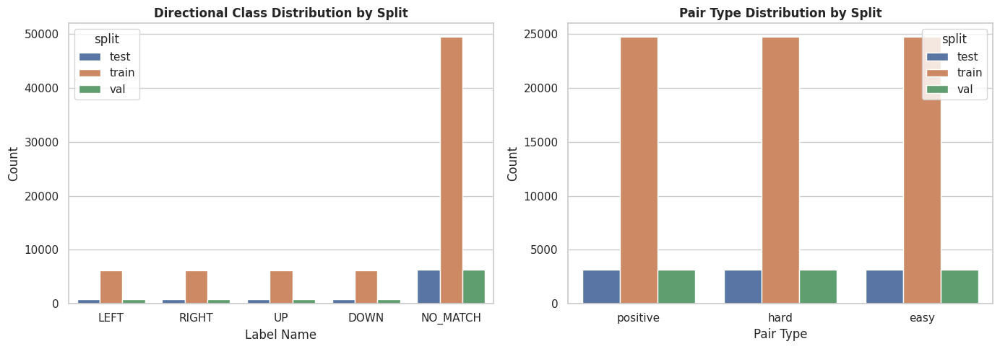

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

def analyze_pairs_distribution(csv_path: str):
    # 1. Load CSV
    df = pd.read_csv(csv_path)

    # Convert label_name to uppercase for consistent counting
    df['label_name'] = df['label_name'].astype(str).str.upper()

    # Define targets
    direction_classes = ['LEFT', 'RIGHT', 'UP', 'DOWN', 'NO_MATCH']
    pair_types = ['positive', 'hard', 'easy']

    # Normalize pair_type names if 'hard_negative' or 'easy_negative' are used
    df['pair_type'] = df['pair_type'].replace({
        'hard_negative': 'hard',
        'easy_negative': 'easy'
    })


    # 1. COUNTS & TABLES
    # --- Directional Class Distribution ---
    class_dist = pd.crosstab(
        df['label_name'],
        df['split'],
        margins=True,
        margins_name='Entire Dataset'
    ).reindex(direction_classes, fill_value=0)

    # Reorder split columns if available
    splits_order = [c for c in ['train', 'val', 'test', 'Entire Dataset'] if c in class_dist.columns]
    class_dist = class_dist[splits_order]

    # Percentage distribution for classes
    class_dist_pct = class_dist.div(class_dist.loc['Entire Dataset'] if 'Entire Dataset' in class_dist.index else class_dist.sum(), axis=1) * 100

    # --- Pair Type Distribution ---
    type_dist = pd.crosstab(
        df['pair_type'],
        df['split'],
        margins=True,
        margins_name='Entire Dataset'
    ).reindex(pair_types, fill_value=0)

    type_dist = type_dist[splits_order]

    # Percentage distribution for pair types
    type_dist_pct = type_dist.div(type_dist.loc['Entire Dataset'] if 'Entire Dataset' in type_dist.index else type_dist.sum(), axis=1) * 100

    print("=" * 60)
    print("          DIRECTIONAL CLASS DISTRIBUTION (COUNTS)          ")
    print("=" * 60)
    print(class_dist.to_string())
    print("\n" + "=" * 60)
    print("        DIRECTIONAL CLASS DISTRIBUTION (PERCENTAGES %)      ")
    print("=" * 60)
    print(class_dist_pct.round(2).to_string())

    print("\n" + "=" * 60)
    print("             PAIR TYPE DISTRIBUTION (COUNTS)               ")
    print("=" * 60)
    print(type_dist.to_string())
    print("\n" + "=" * 60)
    print("           PAIR TYPE DISTRIBUTION (PERCENTAGES %)          ")
    print("=" * 60)
    print(type_dist_pct.round(2).to_string())


    # 2. DISTRIBUTION CHECKS
    print("\n" + "=" * 60)
    print("                   ANALYSIS REPORT                         ")
    print("=" * 60)

    # --- Check 1: Dominant Class ---
    entire_counts = class_dist['Entire Dataset']
    total_samples = len(df)
    max_class = entire_counts.idxmax()
    max_count = entire_counts.max()
    max_pct = (max_count / total_samples) * 100

    print(f"• Dominant Class Check:")
    print(f"  - Most frequent class: '{max_class}' with {max_count:,} samples ({max_pct:.2f}% of dataset).")

    if max_pct > 50:
        print(f"  - [WARNING] Class '{max_class}' dominates the dataset (> 50%). "
              "Consider downsampling negative samples or using weighted loss during training.")
    else:
        print("  - [PASS] No single direction dominates unexpectedly relative to negative setup.")

    # --- Check 2: Train/Val/Test Similarity ---
    print("\n• Train/Val/Test Split Similarity Check:")

    available_splits = [s for s in ['train', 'val', 'test'] if s in class_dist_pct.columns]

    if len(available_splits) > 1:
        # Compare percentages across splits
        max_diff_class = 0.0
        for cls in direction_classes:
            pcts = [class_dist_pct.loc[cls, s] for s in available_splits]
            diff = max(pcts) - min(pcts)
            if diff > max_diff_class:
                max_diff_class = diff

        if max_diff_class < 5.0:
            print(f"  - [PASS] Class distributions across {available_splits} are highly similar "
                  f"(Max variation: {max_diff_class:.2f}%).")
        else:
            print(f"  - [WARNING] Noticeable discrepancy across splits (Max variation: {max_diff_class:.2f}%).")
    else:
        print("  - [INFO] Fewer than 2 splits found in data. Skipping split comparison.")


    # 3. PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Class Distribution per Split
    df_plot_class = df.groupby(['split', 'label_name']).size().reset_index(name='count')
    sns.barplot(
        data=df_plot_class,
        x='label_name',
        y='count',
        hue='split',
        order=direction_classes,
        ax=axes[0]
    )
    axes[0].set_title("Directional Class Distribution by Split", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Label Name")
    axes[0].set_ylabel("Count")

    # Plot 2: Pair Type Distribution per Split
    df_plot_type = df.groupby(['split', 'pair_type']).size().reset_index(name='count')
    sns.barplot(
        data=df_plot_type,
        x='pair_type',
        y='count',
        hue='split',
        order=pair_types,
        ax=axes[1]
    )
    axes[1].set_title("Pair Type Distribution by Split", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Pair Type")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run the analysis
analyze_pairs_distribution("/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/pairs.csv")

The generated dataset contains equal numbers of positive, hard-negative, and easy-negative pair types. Since both negative types belong to the NO_MATCH class, the resulting five-class distribution is intentionally imbalanced, with NO_MATCH representing 66.67% of samples. This distribution will initially be retained to preserve negative-example diversity; class weighting or sampling can be investigated during model training if per-class performance indicates a problem.

In [ ]:
from PIL import Image

def display_pair_spatially(row_data):
    """
    Displays a pair of tiles in their true spatial orientation
    and prints image metadata (including both image IDs for NO_MATCH pairs).
    """
    label = row_data['label_name'].upper()
    pair_type = row_data['pair_type'].capitalize()

    print(f"Label: {label}")
    print(f"Type: {pair_type}")

    # Print both image IDs for NO_MATCH pairs (or when images differ)
    if label == "NO_MATCH" or row_data['image_id_a'] != row_data['image_id_b']:
        print(f"Image A: {row_data['image_id_a']}")
        print(f"Image B: {row_data['image_id_b']}")
    else:
        print(f"Image: {row_data['image_id_a']}")

    print("-" * 30)

    # Load images
    img_a = Image.open(row_data['tile_path_a'])
    img_b = Image.open(row_data['tile_path_b'])

    title_a = f"Tile A\n({row_data['row_a']}, {row_data['col_a']})"
    title_b = f"Tile B\n({row_data['row_b']}, {row_data['col_b']})"

    # --- Determine Grid Layout Based on Label ---
    if label == "LEFT":
        # Tile B is to the LEFT of Tile A -> Render [Tile B | Tile A]
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        first_img, first_title = img_b, title_b
        second_img, second_title = img_a, title_a

    elif label == "RIGHT":
        # Tile B is to the RIGHT of Tile A -> Render [Tile A | Tile B]
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        first_img, first_title = img_a, title_a
        second_img, second_title = img_b, title_b

    elif label == "UP":
        # Tile B is UP relative to Tile A -> Render vertically [Tile B / Tile A]
        fig, axes = plt.subplots(2, 1, figsize=(3, 6))
        first_img, first_title = img_b, title_b
        second_img, second_title = img_a, title_a

    elif label == "DOWN":
        # Tile B is DOWN relative to Tile A -> Render vertically [Tile A / Tile B]
        fig, axes = plt.subplots(2, 1, figsize=(3, 6))
        first_img, first_title = img_a, title_a
        second_img, second_title = img_b, title_b

    else:
        # NO_MATCH / Negatives -> Default horizontal layout [Tile A | Tile B]
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        first_img, first_title = img_a, title_a
        second_img, second_title = img_b, title_b

    # Render top/left image
    axes[0].imshow(first_img)
    axes[0].set_title(first_title, fontsize=10)
    axes[0].axis('off')

    # Render bottom/right image
    axes[1].imshow(second_img)
    axes[1].set_title(second_title, fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


   SAMPLING 2 RANDOM POSITIVE PAIRS
Label: LEFT
Type: Positive
Image: img_80
------------------------------


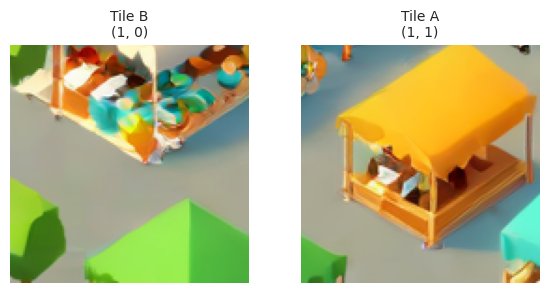

Label: UP
Type: Positive
Image: img_284
------------------------------


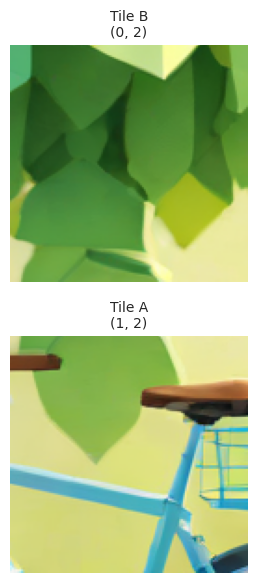


   SAMPLING 2 RANDOM HARD PAIRS
Label: NO_MATCH
Type: Hard
Image A: img_564
Image B: img_564
------------------------------


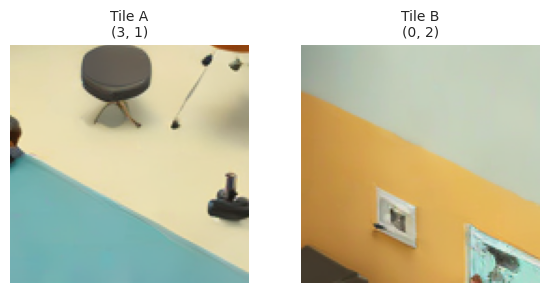

Label: NO_MATCH
Type: Hard
Image A: img_525
Image B: img_525
------------------------------


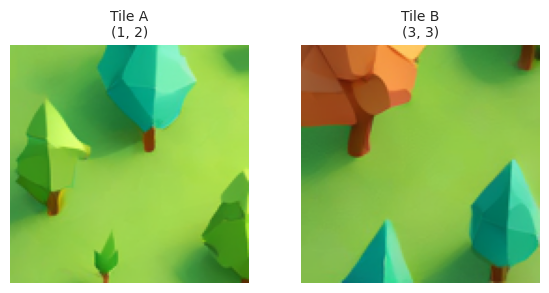


   SAMPLING 2 RANDOM EASY PAIRS
Label: NO_MATCH
Type: Easy
Image A: img_325
Image B: img_469
------------------------------


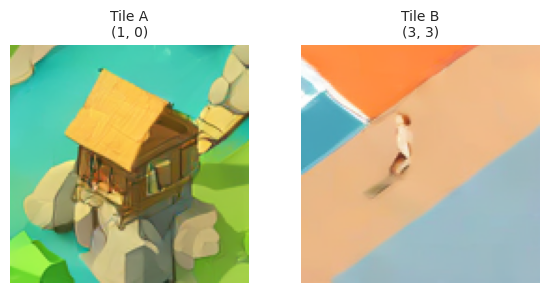

Label: NO_MATCH
Type: Easy
Image A: img_99
Image B: img_155
------------------------------


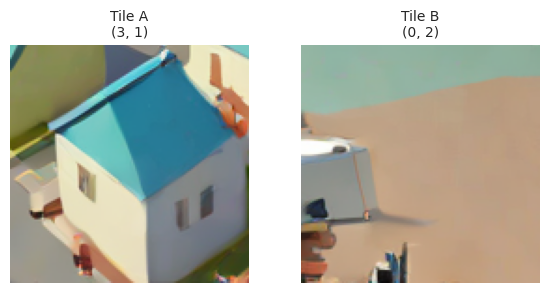


   SAMPLING 5 RANDOM EXAMPLES FROM CLASS: RIGHT
Label: RIGHT
Type: Positive
Image: img_344
------------------------------


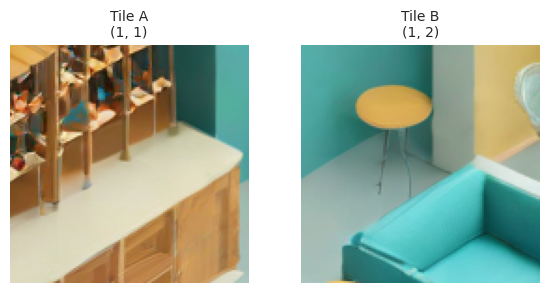

Label: RIGHT
Type: Positive
Image: img_319
------------------------------


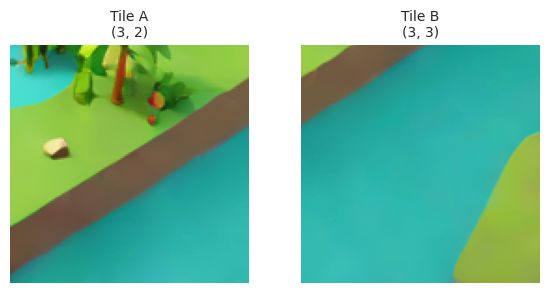

Label: RIGHT
Type: Positive
Image: img_26
------------------------------


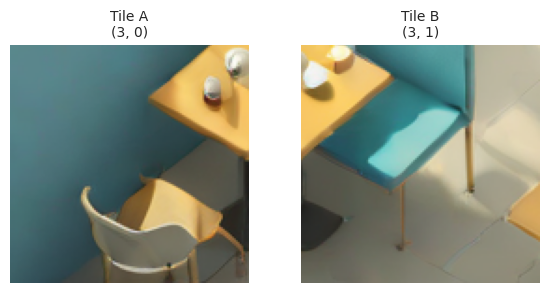

Label: RIGHT
Type: Positive
Image: img_583
------------------------------


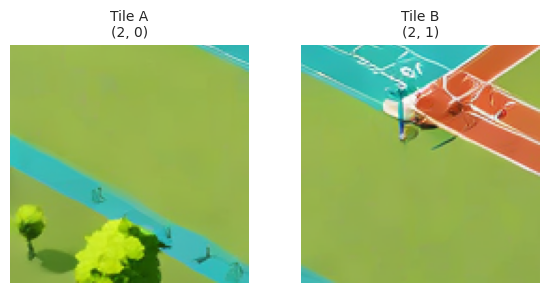

Label: RIGHT
Type: Positive
Image: img_562
------------------------------


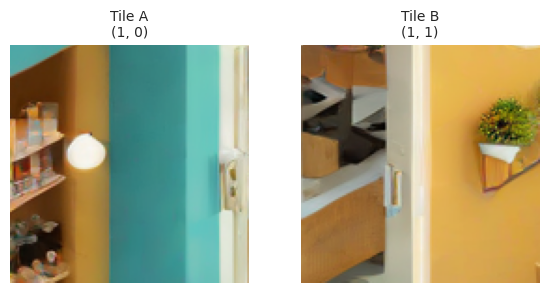


   SAMPLING 5 RANDOM EXAMPLES FROM CLASS: DOWN
Label: DOWN
Type: Positive
Image: img_644
------------------------------


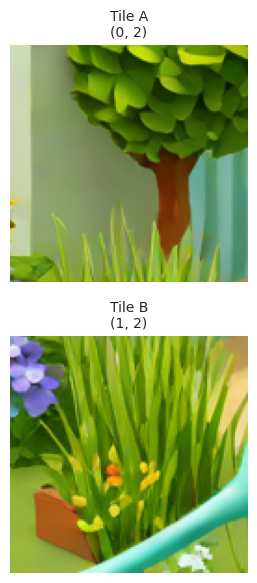

Label: DOWN
Type: Positive
Image: img_548
------------------------------


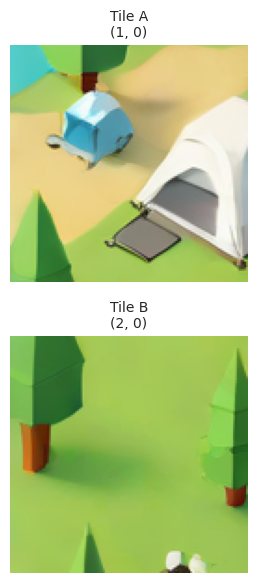

Label: DOWN
Type: Positive
Image: img_185
------------------------------


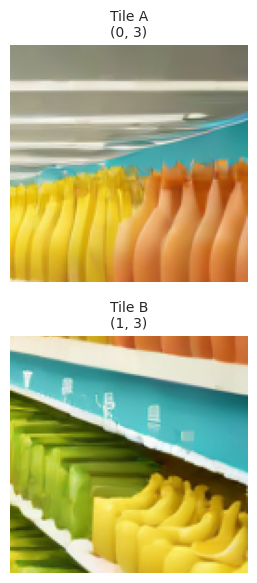

Label: DOWN
Type: Positive
Image: img_265
------------------------------


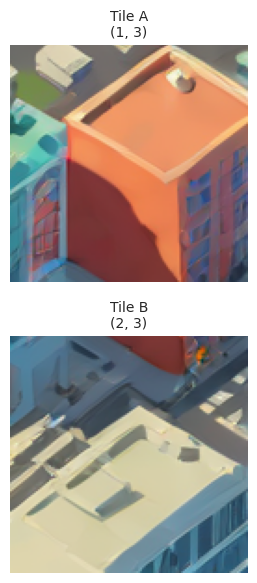

Label: DOWN
Type: Positive
Image: img_590
------------------------------


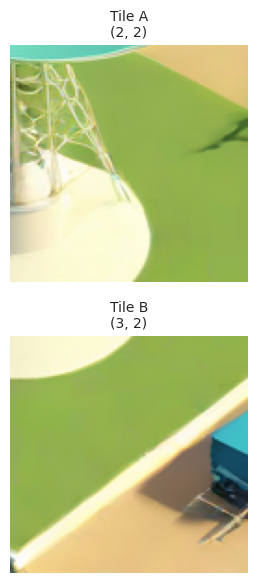


   SAMPLING 5 RANDOM EXAMPLES FROM CLASS: no_match
Label: NO_MATCH
Type: Hard
Image A: img_177
Image B: img_177
------------------------------


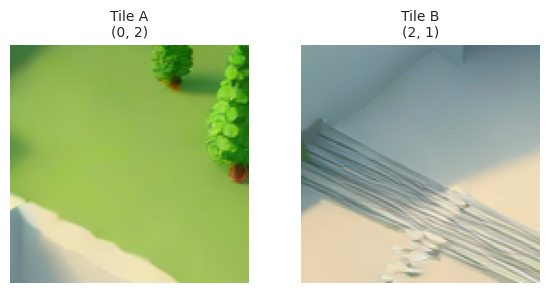

Label: NO_MATCH
Type: Hard
Image A: img_553
Image B: img_553
------------------------------


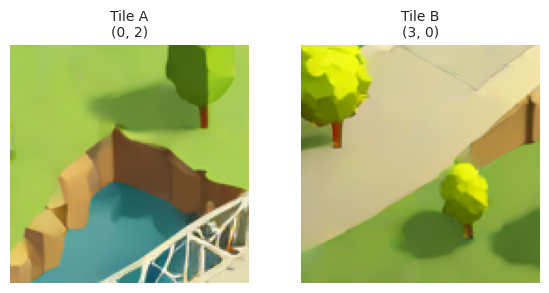

Label: NO_MATCH
Type: Easy
Image A: img_409
Image B: img_154
------------------------------


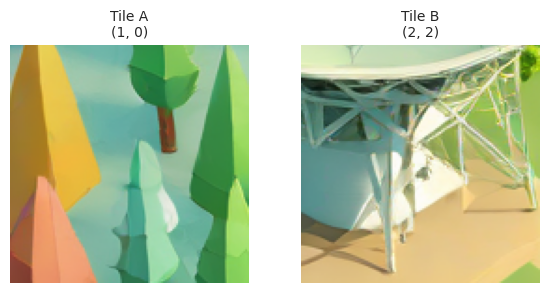

Label: NO_MATCH
Type: Easy
Image A: img_495
Image B: img_134
------------------------------


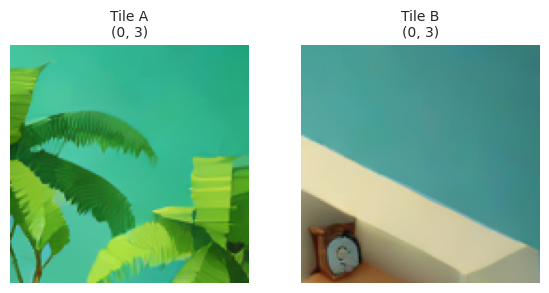

Label: NO_MATCH
Type: Easy
Image A: img_591
Image B: img_52
------------------------------


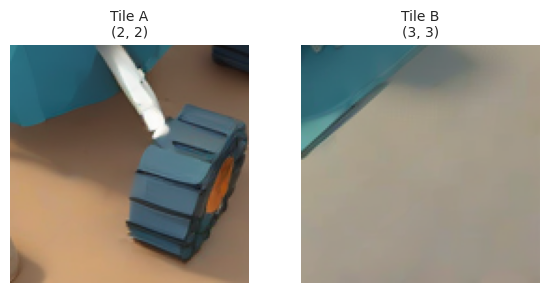


   SAMPLING 5 RANDOM EXAMPLES FROM CLASS: LEFT
Label: LEFT
Type: Positive
Image: img_161
------------------------------


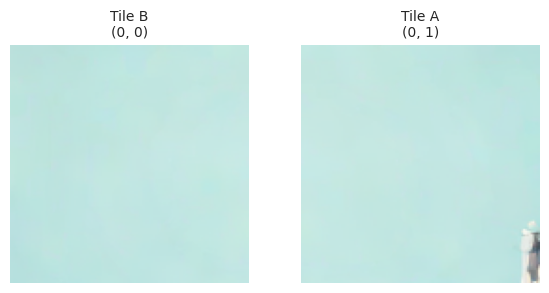

Label: LEFT
Type: Positive
Image: img_377
------------------------------


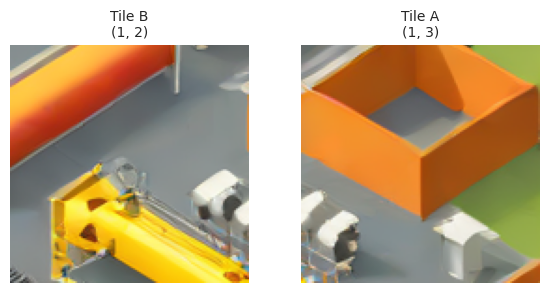

Label: LEFT
Type: Positive
Image: img_146
------------------------------


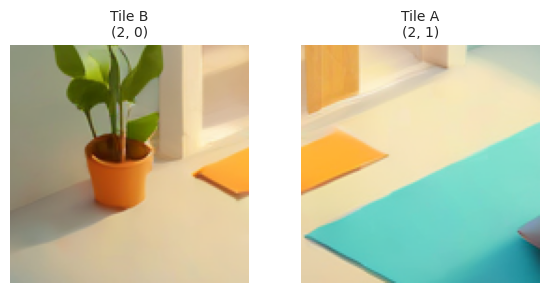

Label: LEFT
Type: Positive
Image: img_311
------------------------------


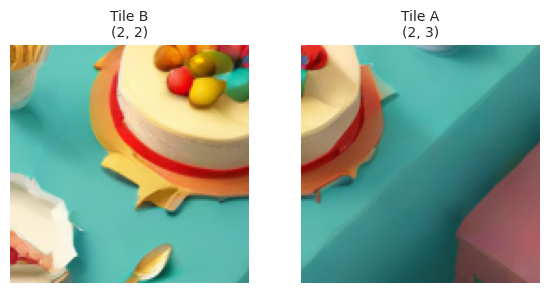

Label: LEFT
Type: Positive
Image: img_173
------------------------------


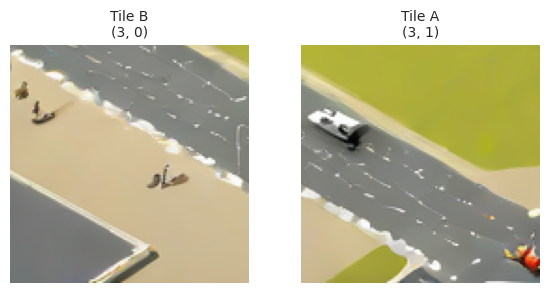


   SAMPLING 5 RANDOM EXAMPLES FROM CLASS: UP
Label: UP
Type: Positive
Image: img_246
------------------------------


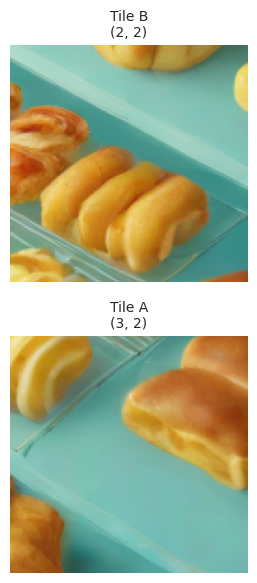

Label: UP
Type: Positive
Image: img_17
------------------------------


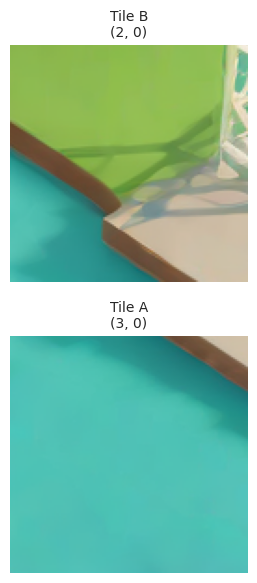

Label: UP
Type: Positive
Image: img_613
------------------------------


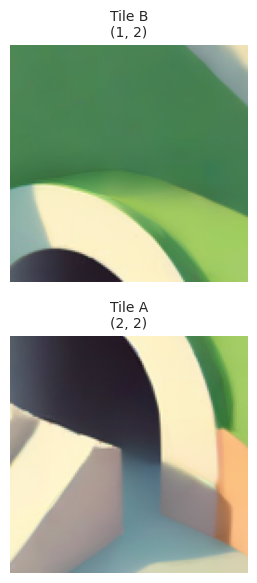

Label: UP
Type: Positive
Image: img_157
------------------------------


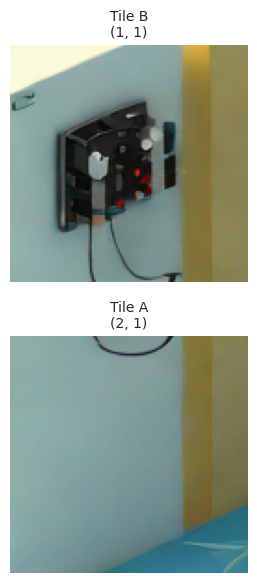

Label: UP
Type: Positive
Image: img_143
------------------------------


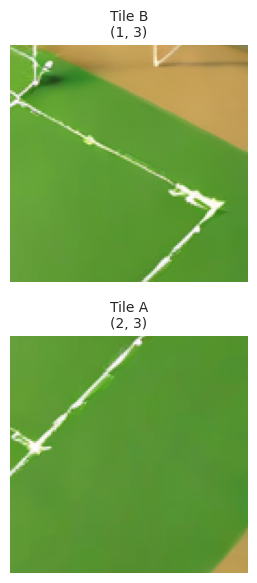

In [ ]:
# SAMPLING & VISUALIZATION EXECUTION

df = pd.read_csv("/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/pairs.csv")

# Standardize pair_type column values for consistent filtering
df['pair_type'] = df['pair_type'].replace({
    'hard_negative': 'hard',
    'easy_negative': 'easy'
})

# 1. Display by Pair Type (2 Samples Each)
pair_types_to_sample = ['positive', 'hard', 'easy']

for p_type in pair_types_to_sample:
    print(f"\n==========================================")
    print(f"   SAMPLING 2 RANDOM {p_type.upper()} PAIRS")
    print(f"==========================================")

    subset = df[df['pair_type'] == p_type]
    samples = subset.sample(n=min(2, len(subset)))

    for _, row in samples.iterrows():
        display_pair_spatially(row)

# 2. Display by Class (5 Samples Each Class)
classes_to_sample = df['label_name'].unique()

for label_cls in classes_to_sample:
    print(f"\n==========================================")
    print(f"   SAMPLING 5 RANDOM EXAMPLES FROM CLASS: {label_cls}")
    print(f"==========================================")

    subset = df[df['label_name'] == label_cls]
    samples = subset.sample(n=min(5, len(subset)))

    for _, row in samples.iterrows():
        display_pair_spatially(row)